# BirdCLEF 2026 — EfficientNet-B0 Baseline
Transfer-learning baseline: ImageNet-pretrained EfficientNet-B0 on 5s log-mel segments, BCE multi-label, validated on held-out labeled soundscapes (macro ROC-AUC).

## 0. Install & Imports

In [ ]:
# At the top of the Colab notebook, mount Drive if needed:
from google.colab import drive
# drive.mount('/content/dri ve')

### NOTE #####
# Uncomment to Mount Google Drive (permissions needed)

In [8]:
# # Kaggle/Colab: timm provides EfficientNet backbones + pretrained weights
# !pip install -q timm

In [9]:
import os, math, random, warnings
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
import timm
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

## 1. Config

In [ ]:
CFG = {
    "seed": 42,
    "base": Path("/content/drive/MyDrive/Kaggle/birdclef-2026"),
    # audio
    "sr": 32000,
    "segment_sec": 5,
    "n_mels": 128,
    "n_fft": 2048,
    "hop_length": 512,
    "fmin": 20,
    "fmax": 16000,
    "in_chans": 3,          # repeat mel to 3ch to keep pretrained stem weights
    # model
    "backbone": "efficientnet_b0",
    "model_tag": "effnet_b0",
    "pretrained": True,
    # training
    "batch_size": 32,
    "epochs": 10,
    "lr": 1e-3,
    "weight_decay": 1e-2,
    "val_fraction": 0.2,   # fraction of labeled soundscape FILES held out for val
    "num_workers": 4,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "cache_dir": Path("/content/drive/MyDrive/Kaggle/birdclef-2026/mel_cache"),
    "ckpt_dir": Path("/content/drive/MyDrive/Kaggle/birdclef-2026/checkpoints"),
}

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

seed_everything(CFG["seed"])

BASE                    = CFG["base"]
TRAIN_AUDIO             = BASE / "train_audio"
TRAIN_SOUNDSCAPES       = BASE / "train_soundscapes"
TRAIN_SOUNDSCAPE_LABELS = BASE / "train_soundscapes_labels.csv"
TRAIN_META              = BASE / "train.csv"
SAMPLE_SUB              = BASE / "sample_submission.csv"

## 2. Scored species (from submission columns)

In [11]:
# Scored species come from the submission columns, NOT from train metadata.
sample_sub = pd.read_csv(SAMPLE_SUB)
SPECIES = [c for c in sample_sub.columns if c != "row_id"]
NUM_CLASSES = len(SPECIES)
species_to_idx = {s: i for i, s in enumerate(SPECIES)}
print(f"{NUM_CLASSES} scored species")

234 scored species


## 3. Data prep — training pool + soundscape val split
XC/iNat clips are weak whole-recording labels. Labeled soundscapes are the only test-matched data, split by **file** so no recording spans train and val.

In [12]:
# ---- Training pool: XC/iNat clips (weak, one primary_label per file) ----
meta = pd.read_csv(TRAIN_META)
meta = meta[meta["primary_label"].isin(species_to_idx)].reset_index(drop=True)
meta["path"] = meta["filename"].map(lambda f: str(TRAIN_AUDIO / f))

# ---- Soundscapes: strong per-segment multi-label; the only test-matched data ----
ss = pd.read_csv(TRAIN_SOUNDSCAPE_LABELS)
ss["path"] = ss["filename"].map(lambda f: str(TRAIN_SOUNDSCAPES / f))

def to_seconds(t):
    if isinstance(t, str) and ":" in t:
        h, m, s = t.split(":")
        return int(h)*3600 + int(m)*60 + float(s)
    return float(t)

ss["start"] = ss["start"].map(to_seconds)

# Split soundscapes by FILE (not segment) to avoid within-recording leakage.
gss = GroupShuffleSplit(n_splits=1, test_size=CFG["val_fraction"], random_state=CFG["seed"])
tr_idx, va_idx = next(gss.split(ss, groups=ss["filename"]))
ss_train, ss_val = ss.iloc[tr_idx].reset_index(drop=True), ss.iloc[va_idx].reset_index(drop=True)
print(f"train clips: {len(meta)} | soundscape segs -> train {len(ss_train)}  val {len(ss_val)}")

train clips: 35549 | soundscape segs -> train 1182  val 296


## 4. Cache key

Same tag as preprocessing; points at the folder already filled. No Mel functions needed here. 

In [13]:
# Cache location + key. Folder name encodes mel params so a param change -> fresh cache.
# NOTE: the split (seed, val_fraction) must match between the two notebooks, or the
# sstr_/ssva_ keys will not line up. The counts printed above are the alignment check.
tag = f"m{CFG['n_mels']}_h{CFG['hop_length']}_f{CFG['fmax']}_s{CFG['segment_sec']}"
CACHE = CFG["cache_dir"] / tag
CACHE.mkdir(parents=True, exist_ok=True)

def cache_path(kind, idx):
    return CACHE / f"{kind}_{idx}.npy"

In [14]:
# def load_segment(path, sr, seg_len, offset=None, random_crop=False):
#     """Load a fixed-length waveform segment, pad/crop as needed."""
#     dur = librosa.get_duration(path=path)
#     if offset is None:
#         max_off = max(0.0, dur - seg_len)
#         offset = random.uniform(0, max_off) if random_crop else 0.0
#     y, _ = librosa.load(path, sr=sr, offset=offset, duration=seg_len)
#     target = int(sr * seg_len)
#     if len(y) < target:
#         y = np.pad(y, (0, target - len(y)))
#     return y[:target]

# def wav_to_mel(y, cfg):
#     m = librosa.feature.melspectrogram(
#         y=y, sr=cfg["sr"], n_fft=cfg["n_fft"], hop_length=cfg["hop_length"],
#         n_mels=cfg["n_mels"], fmin=cfg["fmin"], fmax=cfg["fmax"])
#     m = librosa.power_to_db(m, ref=np.max)
#     m = (m - m.mean()) / (m.std() + 1e-6)
#     return m.astype(np.float32)

In [15]:
# # Cache mels once. Folder name encodes params so a param change -> fresh cache.
# tag = f"m{CFG['n_mels']}_h{CFG['hop_length']}_f{CFG['fmax']}_s{CFG['segment_sec']}"
# CACHE = CFG["cache_dir"] / tag
# CACHE.mkdir(parents=True, exist_ok=True)

# def cache_path(kind, idx):
#     return CACHE / f"{kind}_{idx}.npy"

# def precompute(df, kind, use_start):
#     for i, r in df.iterrows():
#         p = cache_path(kind, i)
#         if p.exists():
#             continue
#         offset = float(r["start"]) if use_start else None
#         y = load_segment(r["path"], CFG["sr"], CFG["segment_sec"],
#                          offset=offset, random_crop=False)
#         np.save(p, wav_to_mel(y, CFG).astype(np.float16))

# precompute(meta,     "clip", use_start=False)
# precompute(ss_train, "sstr", use_start=True)
# precompute(ss_val,   "ssva", use_start=True)
# print("cache ready:", CACHE)

## 5. Datasets & loaders
Val target is true multi-hot (semicolon codes); clip target is single-positive multi-hot.

In [16]:
class ClipDataset(Dataset):
    def __init__(self, df, cfg):
        self.df, self.cfg = df, cfg
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        m = np.load(cache_path("clip", self.df.index[i])).astype(np.float32)
        x = torch.from_numpy(m).unsqueeze(0).repeat(self.cfg["in_chans"], 1, 1)
        t = torch.zeros(NUM_CLASSES)
        t[species_to_idx[r["primary_label"]]] = 1.0
        return x, t

class SoundscapeDataset(Dataset):
    def __init__(self, df, cfg, kind):
        self.df, self.cfg, self.kind = df, cfg, kind
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        m = np.load(cache_path(self.kind, self.df.index[i])).astype(np.float32)
        x = torch.from_numpy(m).unsqueeze(0).repeat(self.cfg["in_chans"], 1, 1)
        t = torch.zeros(NUM_CLASSES)
        for c in str(r["primary_label"]).split(";"):
            if c in species_to_idx:
                t[species_to_idx[c]] = 1.0
        return x, t

train_ds = torch.utils.data.ConcatDataset([
    ClipDataset(meta, CFG),
    SoundscapeDataset(ss_train, CFG, "sstr"),
])
val_ds = SoundscapeDataset(ss_val, CFG, "ssva")

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,
                          num_workers=os.cpu_count(), pin_memory=True,
                          drop_last=True, persistent_workers=True)
val_loader   = DataLoader(val_ds, batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=os.cpu_count(), pin_memory=True,
                          persistent_workers=True)

## 6. Model

In [17]:
class BirdModel(nn.Module):
    def __init__(self, cfg, num_classes):
        super().__init__()
        self.backbone = timm.create_model(
            cfg["backbone"], pretrained=cfg["pretrained"],
            num_classes=num_classes, in_chans=cfg["in_chans"])
    def forward(self, x):
        return self.backbone(x)

model = BirdModel(CFG, NUM_CLASSES).to(CFG["device"])

model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

## 7. Loss, optimizer, metric

In [18]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"],
                              weight_decay=CFG["weight_decay"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG["epochs"])
scaler = torch.cuda.amp.GradScaler(enabled=CFG["device"] == "cuda")

# def macro_auc(y_true, y_prob):
#     # Macro ROC-AUC over columns that have both classes present in val.
#     aucs = []
#     for j in range(y_true.shape[1]):
#         if y_true[:, j].sum() > 0 and y_true[:, j].sum() < len(y_true):
#             aucs.append(roc_auc_score(y_true[:, j], y_prob[:, j]))
#     return float(np.mean(aucs)) if aucs else 0.0

def macro_auc(y_true, y_prob):
    # Official metric: macro ROC-AUC over species with >=1 true positive.
    scored = [j for j in range(y_true.shape[1]) if y_true[:, j].sum() > 0]
    return roc_auc_score(y_true[:, scored], y_prob[:, scored], average="macro")

## 8. Train / validate

In [ ]:
def run_epoch(loader, train):
    model.train() if train else model.eval()
    total, ys, ps = 0.0, [], []
    for x, t in loader:
        x, t = x.to(CFG["device"]), t.to(CFG["device"])
        with torch.set_grad_enabled(train), torch.cuda.amp.autocast(enabled=CFG["device"]=="cuda"):
            out = model(x)
            loss = criterion(out, t)
        if train:
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update()
        total += loss.item() * len(x)
        if not train:
            ys.append(t.cpu().numpy()); ps.append(torch.sigmoid(out).float().cpu().numpy())
    avg = total / len(loader.dataset)
    if train:
        return avg, None
    return avg, macro_auc(np.vstack(ys), np.vstack(ps))

best_auc = 0.0
history = []
for epoch in range(CFG["epochs"]):
    tr_loss, _ = run_epoch(train_loader, train=True)
    va_loss, va_auc = run_epoch(val_loader, train=False)
    scheduler.step()
    history.append({"epoch": epoch+1, "train_loss": tr_loss, "val_loss": va_loss, "val_auc": va_auc})
    print(f"epoch {epoch+1:02d} | train {tr_loss:.4f} | val {va_loss:.4f} | macroAUC {va_auc:.4f}")
    # if va_auc > best_auc:
        # best_auc = va_auc
        # torch.save(model.state_dict(), f"best_{CFG['model_tag']}.pt")
    if va_auc > best_auc:
        best_auc = va_auc
        cfg_save = {k: (str(v) if isinstance(v, Path) else v) for k, v in CFG.items()}
        torch.save({"model_state": model.state_dict(), "cfg": cfg_save, "best_auc": best_auc},
                   f"best_{CFG['model_tag']}.pt")

hist = pd.DataFrame(history)
hist.to_csv(f"history_{CFG['model_tag']}.csv", index=False)

epoch 01 | train 0.0237 | val 0.0758 | macroAUC 0.8156
epoch 02 | train 0.0122 | val 0.0678 | macroAUC 0.8545
epoch 03 | train 0.0090 | val 0.0802 | macroAUC 0.8404
epoch 04 | train 0.0070 | val 0.0872 | macroAUC 0.8424
epoch 05 | train 0.0053 | val 0.1044 | macroAUC 0.8011
epoch 06 | train 0.0036 | val 0.0956 | macroAUC 0.8315
epoch 07 | train 0.0022 | val 0.0958 | macroAUC 0.8196
epoch 08 | train 0.0012 | val 0.1108 | macroAUC 0.8057
epoch 09 | train 0.0007 | val 0.1125 | macroAUC 0.8264
epoch 10 | train 0.0005 | val 0.1142 | macroAUC 0.8181


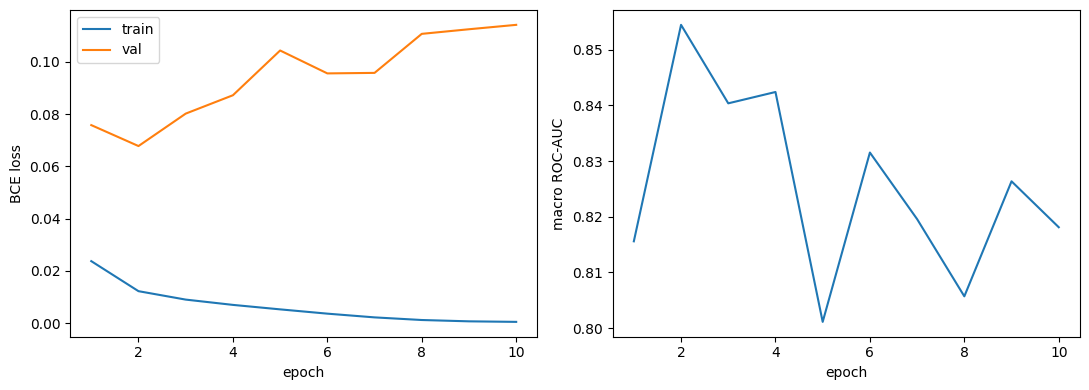

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist["epoch"], hist["train_loss"], label="train")
ax[0].plot(hist["epoch"], hist["val_loss"], label="val")
ax[0].set(xlabel="epoch", ylabel="BCE loss"); ax[0].legend()
ax[1].plot(hist["epoch"], hist["val_auc"])
ax[1].set(xlabel="epoch", ylabel="macro ROC-AUC")
plt.tight_layout(); plt.show()

In [ ]:
# ckpt = torch.load("best_effnet_b0.pt", map_location="cpu")   # your existing weights
# cfg_save = {k: (str(v) if isinstance(v, Path) else v) for k, v in CFG.items()}
# torch.save({"model_state": ckpt, "cfg": cfg_save, "best_auc": best_auc},
#            "best_effnet_b0.pt") 

In [1]:
import os
print(os.getcwd())                          # where relative saves land — probably /content
print([f for f in os.listdir('.') if f.endswith('.pt')])

/content
['best_effnet_b0.pt']
